# Notes Kestra - Module 2 DE Zoomcamp

## Qu'est-ce que Kestra ?

### Définition : Orchestrateur de workflows

**Ce qu'est Kestra :**
- Un orchestrateur de workflows data moderne
- Permet de planifier, exécuter et monitorer des pipelines de données
- Interface graphique pour visualiser et gérer les workflows
- Gestion automatique des retries et de la reprise en cas d'échec

**Ce que Kestra n'est PAS :**
- Pas un outil de transformation de données (il orchestre les outils qui transforment)
- Pas une base de données
- Pas un simple scheduler cron

**Pourquoi c'est utile :**
- Robustesse face aux interruptions
- Visibilité complète sur l'exécution des workflows
- Gestion élégante des erreurs et reprises automatiques
- Permet de gérer des dépendances complexes entre tâches

---

## Expérience Pratique : Résilience de Kestra

### Problème rencontré

Lors du téléchargement répété des données taxi, plusieurs problèmes de connexion se sont produits. Il fallait éteindre et relancer les containers, mais **Kestra a su bien reprendre et tout récupérer** sans perte de données.

### Cause Root : Pool de connexions épuisé

Le téléchargement des données des taxis jaunes entraînait beaucoup de connexions à PostgreSQL, saturant complètement le **HikariPool** (pool de connexions).

### Solution : Configuration des pools de connexions

**Côté Kestra :**
```yaml
kestra:
    environment:
        # ... tes configs existantes ...
        DATASOURCES_POSTGRES_HIKARI_MAXIMUM_POOL_SIZE: 30
        DATASOURCES_POSTGRES_HIKARI_MINIMUM_IDLE: 10
        DATASOURCES_POSTGRES_HIKARI_CONNECTION_TIMEOUT: 60000
```

**Côté PostgreSQL :**
```yaml
kestra_postgres:
    environment:
        POSTGRES_MAX_CONNECTIONS: 100  # Augmentation de la limite
```

### Résultat : Performance doublée

En plus de résoudre le problème de connexion, cette optimisation a permis au flow d'être **2x plus rapide** :
- **Avant :** 12 minutes par exécution
- **Après :** 6 minutes par exécution

> **Note :** Je dois en apprendre plus là-dessus. Bien que j'ai compris l'idée, ça m'a l'air d'être quelque chose d'important pour optimiser les performances des pipelines.

---

## Tips Utiles Appris dans le Cours

### 1. KV Store - Sauvegarde de valeurs réutilisables

**Stockage d'une valeur :**
```yaml
tasks:
  - id: gcp_project_id
    type: io.kestra.plugin.core.kv.Set
    key: GCP_PROJECT_ID
    kvType: STRING
    value: cohesive-folio-485508-e4  # TODO: remplacer avec ton project ID
```

**Appel de la valeur dans un autre flow :**
```yaml
projectId: "{{kv('GCP_PROJECT_ID')}}"
```

### 2. Gestion des Secrets (Service Account GCP)

**Configuration Docker :**
```yaml
kestra:
    env_file: .env_encoded
```

**Utilisation dans le flow :**
```yaml
serviceAccount: "{{ secret('GCP_SERVICE_ACCOUNT') }}"
```

**Guide de configuration :**
Documentation Kestra - Google Credentials : https://kestra.io/docs/how-to-guides/google-credentials

---

## Comparaison Performance : ELT BigQuery vs ETL Local

### ELT BigQuery

La génération du flow ELT par BigQuery est **beaucoup plus rapide** que mon ETL local.

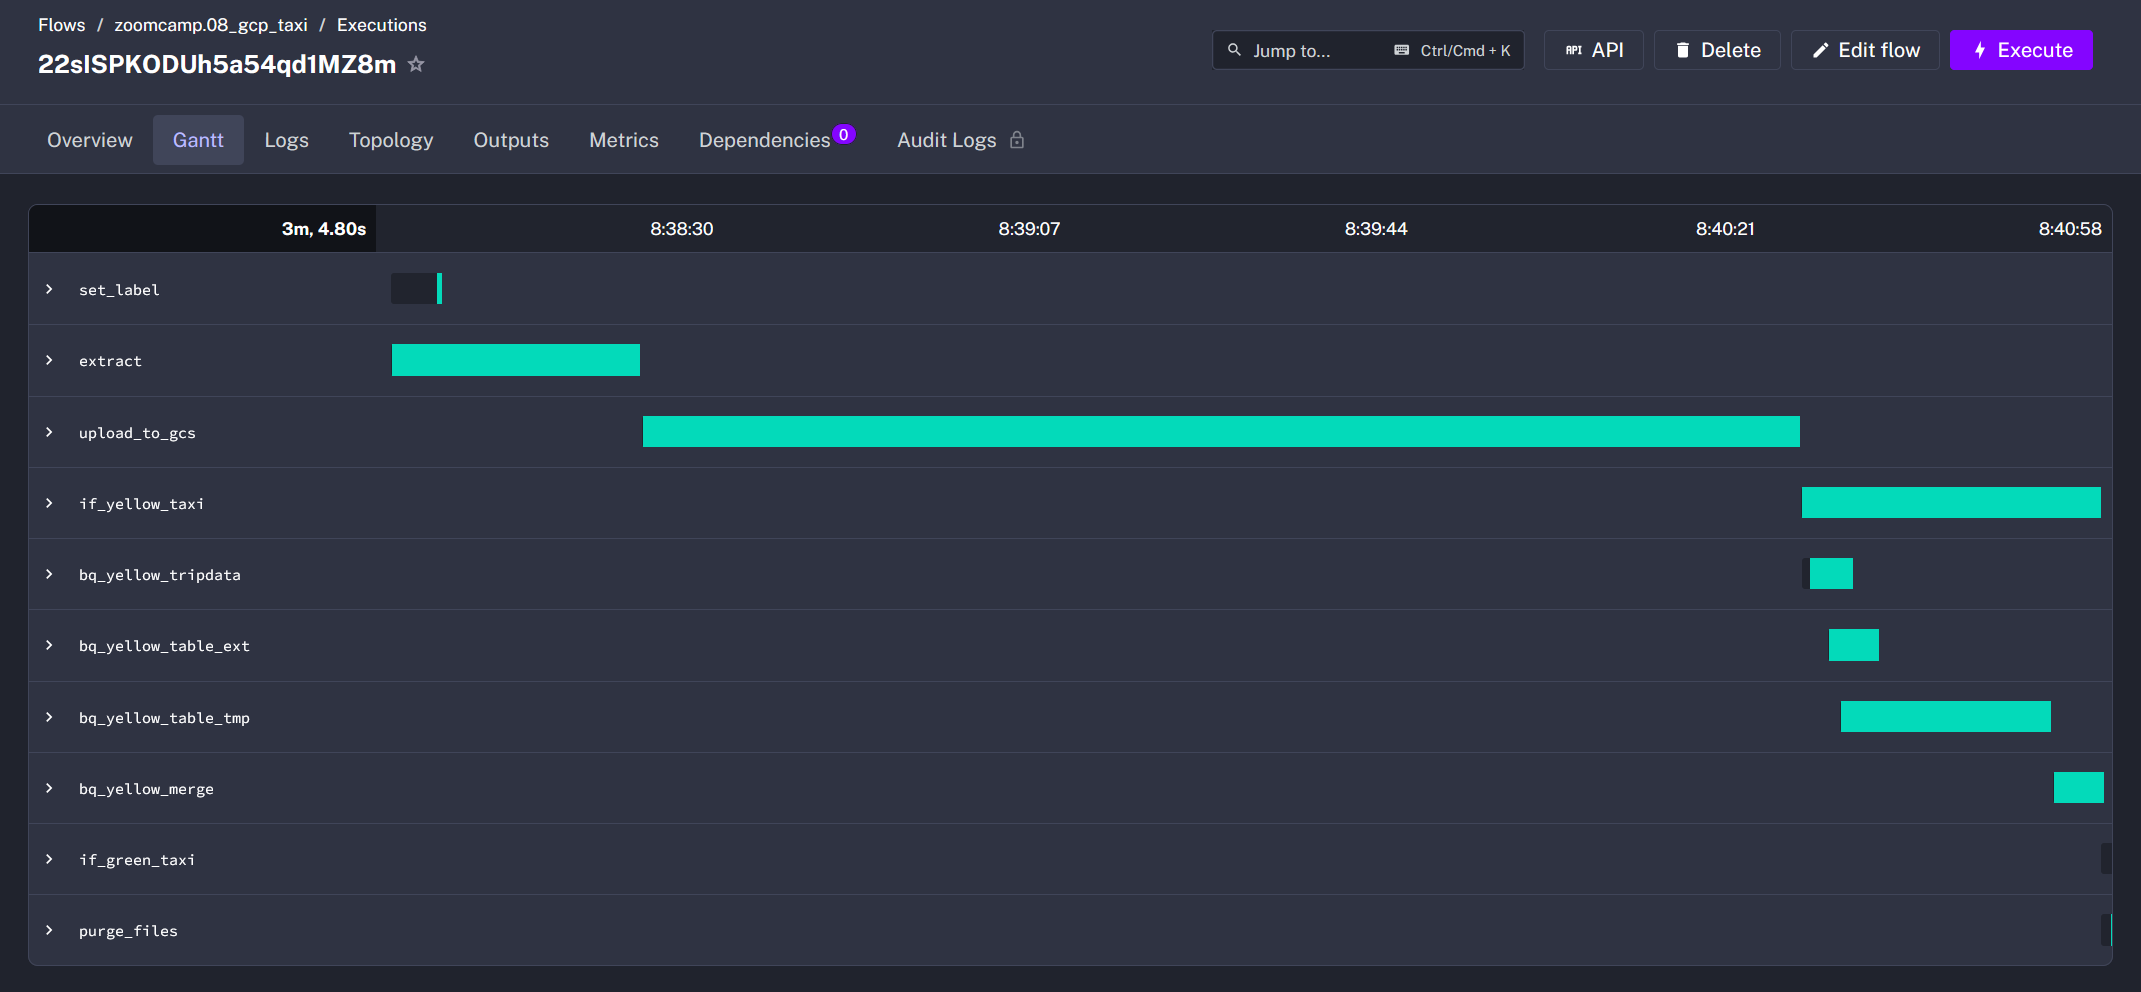

**Goulot d'étranglement identifié :** Ma connexion internet  
Le diagramme de Gantt montre que la plus grosse partie de la tâche est l'**envoi de la donnée vers Google Cloud Storage**.

### ETL Local

Contrairement à l'ELT BigQuery, toute la durée de la tâche est concentrée au niveau du **MERGE** (transformation des données en local avant envoi).

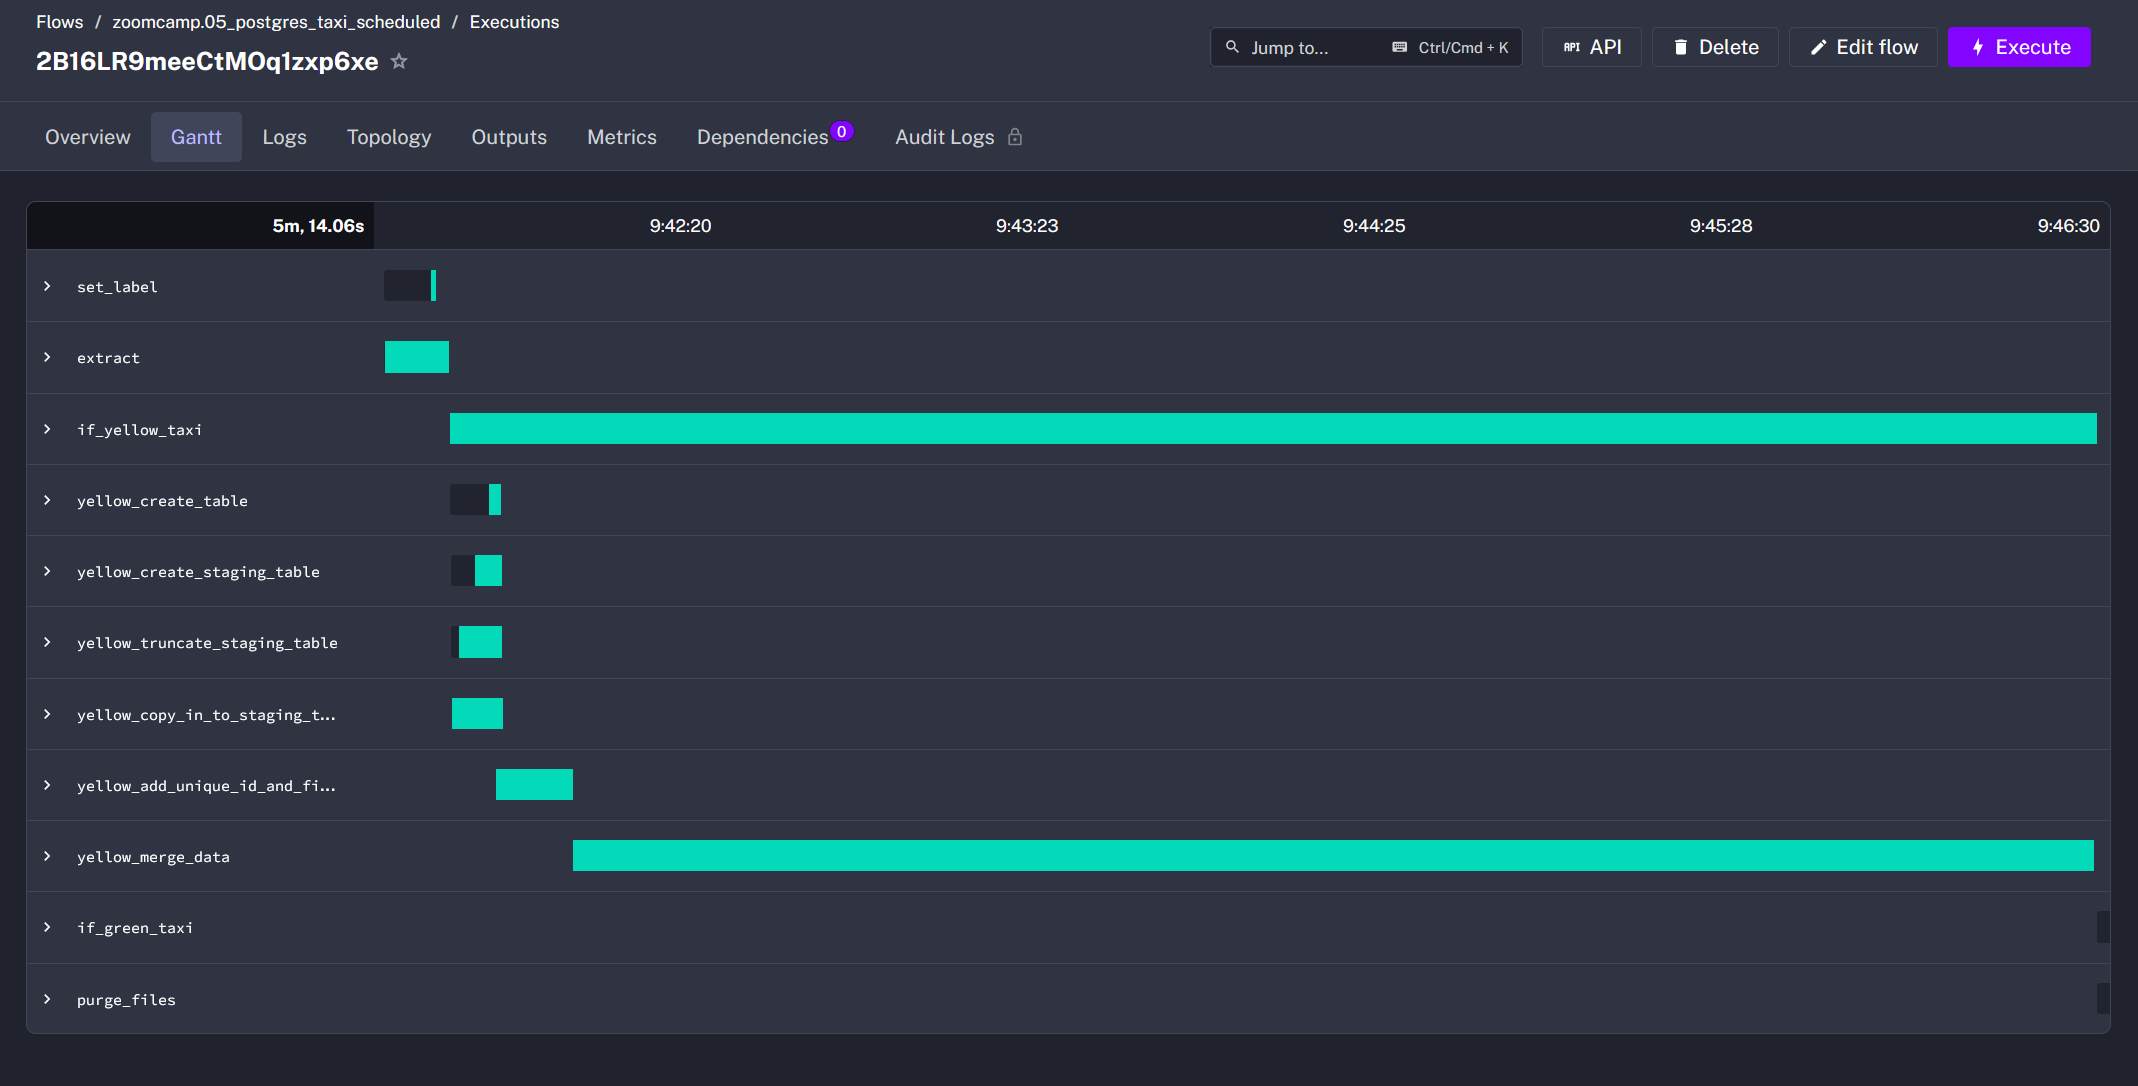

---

## À Retenir

1. **Kestra = Résilience** : Reprises automatiques, gestion élégante des erreurs
2. **HikariPool** : Bien configurer les pools de connexions peut doubler les performances
3. **KV Store** : Pratique pour partager des configs entre flows
4. **Secrets** : Toujours encoder les credentials sensibles
5. **ELT > ETL** (dans le cloud) : Laisser BigQuery faire les transformations est plus rapide que transformer en local

---

*Notes du Module 2 - DataTalks Club DE Zoomcamp*